In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

# Load ML ready data
df_ml = pd.read_csv("data/marvel_ml_ready.csv")

# Split features and target
X = df_ml.drop(columns=["is_high_traffic"])
y = df_ml["is_high_traffic"]

# Train/test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"\nTarget balance in training set:")
print(y_train.value_counts())

✅ Data split!
Training samples: 120
Testing samples:  30

Target balance in training set:
is_high_traffic
1    111
0      9
Name: count, dtype: int64


In [2]:
# Train Model 1 — Logistic Regression
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Train Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_preds))

print("=== Random Forest ===")
print(classification_report(y_test, rf_preds))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        28

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

=== Random Forest ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00        28

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



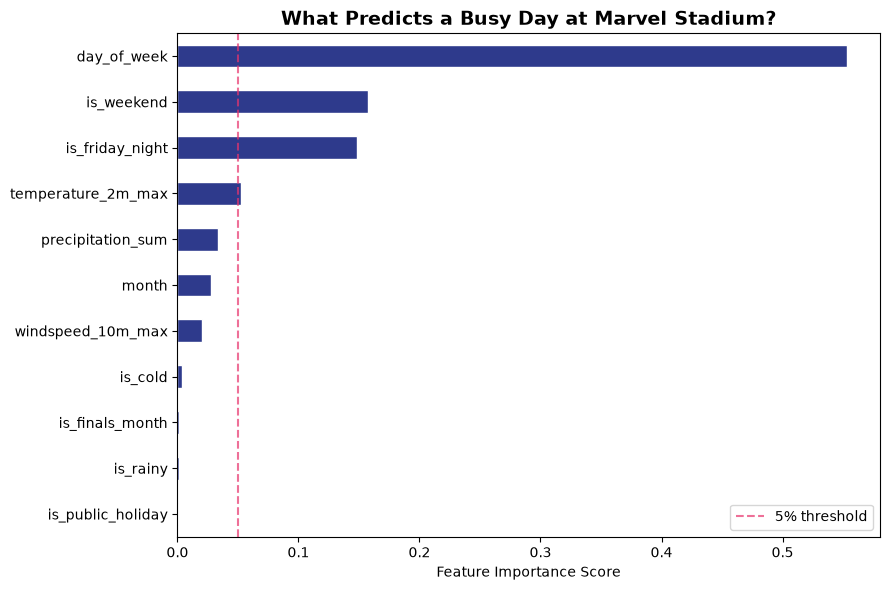

✅ Feature importance chart saved!


In [3]:
# Feature importance chart
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind="barh", color="#2E3A8C", edgecolor="white")
plt.title("What Predicts a Busy Day at Marvel Stadium?", fontsize=14, fontweight="bold")
plt.xlabel("Feature Importance Score")
plt.axvline(x=0.05, color="#E8336D", linestyle="--", alpha=0.7, label="5% threshold")
plt.legend()
plt.tight_layout()
plt.savefig("data/chart6_feature_importance.png", dpi=150)
plt.show()
print("✅ Feature importance chart saved!")

In [4]:
import joblib

# Save both models
joblib.dump(rf, "data/model_random_forest.pkl")
joblib.dump(lr, "data/model_logistic_regression.pkl")

# Save feature column names — needed for the Streamlit app
feature_cols = list(X.columns)
joblib.dump(feature_cols, "data/feature_cols.pkl")

print("✅ Models saved!")
print("Features:", feature_cols)

✅ Models saved!
Features: ['day_of_week', 'month', 'is_weekend', 'is_friday_night', 'is_public_holiday', 'is_rainy', 'is_cold', 'is_finals_month', 'temperature_2m_max', 'precipitation_sum', 'windspeed_10m_max']
